In [17]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.ar_model import AutoReg  # Corrected path and casing
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.graphics.tsaplots as sgt # For ACF/PACF plots

In [18]:
# MultiVariate AR model
tickers = ['^NSEI']
end = dt.date.today()
start = end - dt.timedelta(days=365*5)
df = yf.download(tickers, start = start, end = end)['Close']
df = df.rename(columns={'^NSEI': 'nse',})


[*********************100%***********************]  1 of 1 completed


In [19]:
df[df.isna().any(axis=1)]
df = df.dropna(axis=0, how='any')
r = df.copy()
r['nse'] = np.log(df['nse']/df['nse'].shift(1))
r.dropna(inplace=True)
df1 = r['nse']

result = adfuller(df1.dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Critical Values: {result[2]}")

ADF Statistic: -35.29966189474557
p-value: 0.0
Critical Values: 0


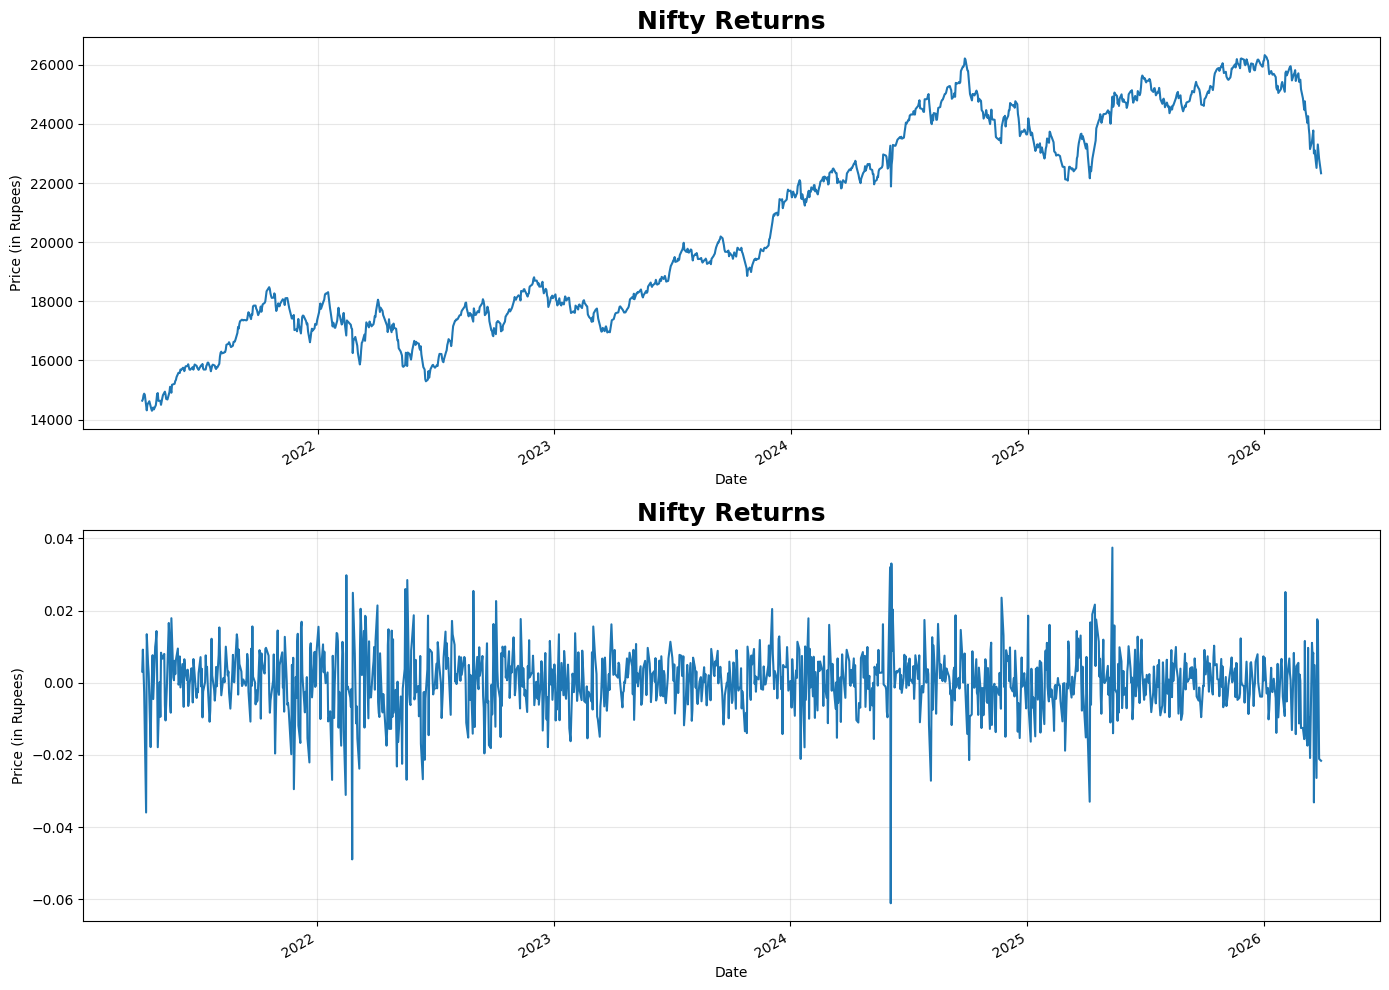

In [20]:
fig, (ax1 , ax2) = plt.subplots(2,1,figsize=(14,10))
df['nse'].plot(ax=ax1, linewidth=1.5)
ax1.set_title("Nifty Returns",fontsize=18, fontweight='bold')
ax1.set_ylabel('Price (in Rupees)')
ax1.grid(True, alpha=0.3)

r['nse'].plot(ax=ax2, linewidth=1.5)
ax2.set_title("Nifty Returns",fontsize=18, fontweight='bold')
ax2.set_ylabel('Price (in Rupees)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:
# ADF test for checking data
result = adfuller(r.dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Critical Values: {result[2]}")

ADF Statistic: -35.29966189474557
p-value: 0.0
Critical Values: 0


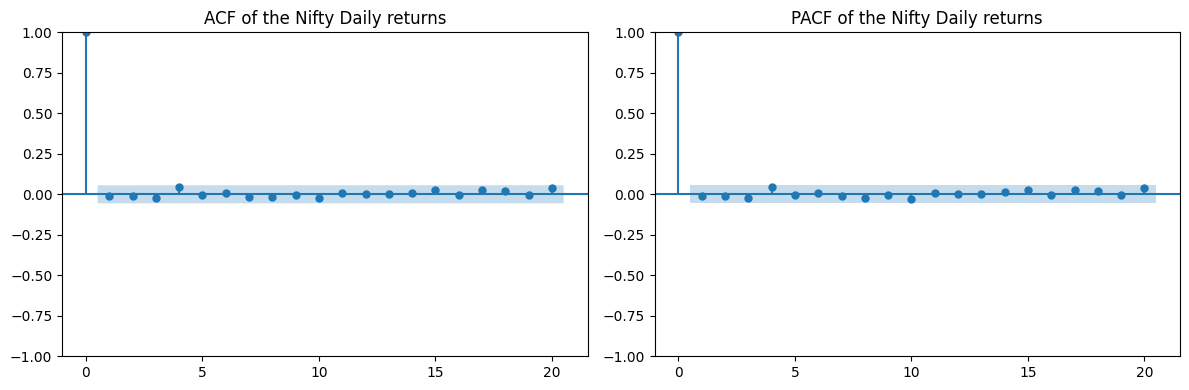

In [22]:
# ACF AND PACF Plot for checking stationarity in data means trend,pattern
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sm.graphics.tsa.plot_acf(r['nse'].dropna(), lags = 20, ax=ax1)
sm.graphics.tsa.plot_pacf(r['nse'].dropna(), lags = 20, ax=ax2)
ax1.set_title(f"ACF of the Nifty Daily returns")
ax2.set_title(f"PACF of the Nifty Daily returns")
plt.tight_layout()
plt.show()

In [23]:
# Split Data
split = int(len(r) * .7)
train_df = r[:split]
test_df = r[split:]

In [24]:
import pandas as pd
import numpy as np
from statsmodels.tsa.ar_model import AutoReg

# 1. Initialize your storage
predictions = []

# 2. Start the rolling loop
# We start at the end of your training set (day 863)
for i in range(len(train_df), len(r)):

    # Define the 60-day "Observation Window"
    # This keeps the model focused on the most recent 'mood'
    window = r.iloc[i-60 : i]

    # Train the model on these 60 days using 3 Lags
    # This captures the 3-day 'ripple' we discussed
    model = AutoReg(window, lags=3).fit()

    # Predict the VERY next day (Step 1)
    # .iloc[0] extracts the single predicted value
    pred = model.forecast(steps=1).iloc[0]

    # Save the guess to our list
    predictions.append(pred)

print(f"Success! Generated {len(predictions)} daily predictions.")

Success! Generated 370 daily predictions.


In [26]:
# Use .values to turn the DataFrame into a flat array
actual_dir = np.sign(test_df.values).flatten()
predicted_dir = np.sign(predictions)

# Now they are both simple lists of numbers, and the math will work!
accuracy = (actual_dir == predicted_dir).mean() * 100
print(f"Directional Accuracy: {accuracy:.2f}%")

Directional Accuracy: 50.00%


In [27]:
print(pd.Series(predictions).value_counts(bins=2))

(-0.00188, 0.00594]     334
(-0.01071, -0.00188]     36
Name: count, dtype: int64


In [28]:
# Create a Series of your predictions
pred_series = pd.Series(predictions)

print("--- Model Bias Check ---")
print(f"Positive Predictions (Up): {len(pred_series[pred_series > 0])}")
print(f"Negative Predictions (Down): {len(pred_series[pred_series < 0])}")

--- Model Bias Check ---
Positive Predictions (Up): 182
Negative Predictions (Down): 188


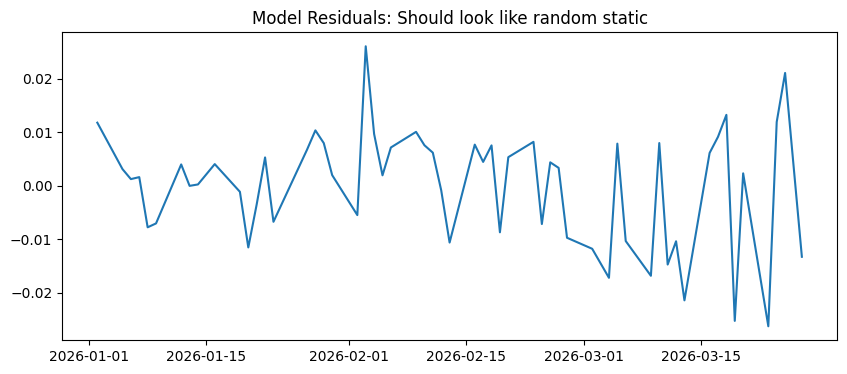

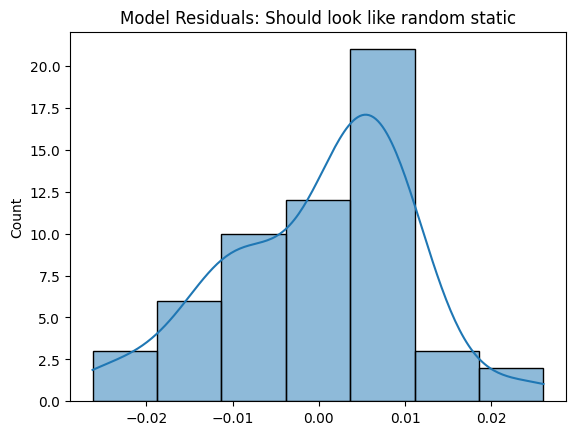

In [30]:
# Get the residuals from your LAST model in the loop
residuals = model.resid

# Plot them
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Model Residuals: Should look like random static")
plt.show()

sns.histplot(residuals,kde=True)
plt.title("Model Residuals: Should look like random static")
plt.show()

In [31]:
# Create a mask for 'quiet' days
quiet_days = np.abs(test_df.values.flatten()) < 0.005 # 0.5% move

# Check accuracy only on those days
quiet_accuracy = (actual_dir[quiet_days] == predicted_dir[quiet_days]).mean() * 100
print(f"Accuracy on Slow Days: {quiet_accuracy:.2f}%")

Accuracy on Slow Days: 50.51%
